In [2]:
!pip install numpy

In [3]:
!pip install numpy pandas matplotlib opencv-python scikit-image scipy

In [4]:
!pip install tensorflow

In [5]:
!pip install neurokit2

In [6]:
## Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skimage
from skimage import io, filters, color
import cv2
import neurokit2 as nk
from scipy.signal import find_peaks, butter, filtfilt, welch
from skimage.morphology import skeletonize

import tensorflow as tf

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [7]:
def load_preprocess(path, clahe=True):
    
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found at: {path}")
    
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply CLAHE (contrast enhancement)
    if clahe:
        clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe_obj.apply(gray)
    
    # Apply median blur (noise reduction)
    gray = cv2.medianBlur(gray, 3)
    
    return img, gray


In [8]:
import os
import glob

folder_path = r"major project/ECG Images of Myocardial Infarction Patients (240x12=2880)"
image_paths = glob.glob(os.path.join(folder_path, "*.jpg"))

processed_images = []
for img_path in image_paths:
    result = load_preprocess(img_path, clahe=True)
    processed_images.append(result)


In [9]:
load_preprocess(r"MI(100)[1].jpg", clahe = True)

(array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
  

In [10]:
img1, gray1 = load_preprocess(r"MI(100)[1].jpg", clahe = True)

In [11]:
from scipy.ndimage import gaussian_filter1d

In [12]:
def estimate_pixels_per_mm(gray):
    """
    Estimate pixels per mm in an ECG image by detecting vertical grid lines.
    
    Parameters:
        gray (ndarray): Grayscale ECG image.
    
    Returns:
        float or None: Estimated pixel spacing per mm, or None if not enough peaks are found.
    """
    # Invert intensity so grid lines stand out
    col_sum = np.sum(255 - gray, axis=0)
    
    # Smooth to reduce noise
    col_smooth = gaussian_filter1d(col_sum, sigma=3)
    
    # Find peaks (vertical grid lines)
    peaks, _ = find_peaks(col_smooth, distance=4, prominence=np.max(col_smooth) * 0.2)
    
    if len(peaks) < 2:
        return None  # not enough lines detected
    
    # Distance between grid lines
    diffs = np.diff(peaks)
    median_diff = np.median(diffs)
    
    return median_diff


In [13]:
pps = estimate_pixels_per_mm(gray1)

In [14]:
def remove_grid_and_inpaint(color_img, gray, small_box_px): 
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(max(3, small_box_px)), 1))
    horiz_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, horiz_kernel, iterations=1)
    vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(max(3, small_box_px))))
    vert_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, vert_kernel, iterations=1)
    grid_mask = cv2.bitwise_or(horiz_lines, vert_lines)
 
    grid_mask = (grid_mask > 0).astype('uint8') * 255
    inpainted = cv2.inpaint(color_img, grid_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    inpaint_gray = cv2.cvtColor(inpainted, cv2.COLOR_BGR2GRAY)
    return inpainted, inpaint_gray

In [15]:
grid1, inpaint1 = remove_grid_and_inpaint(img1, gray1, pps )

In [16]:
from skimage.util import invert
from skimage.filters import threshold_otsu

def extract_waveform_pixels(gray_img):
   
    thresh = threshold_otsu(gray_img)
    bw = gray_img < thresh  
    skeleton = skeletonize(bw)
   
    h, w = skeleton.shape
    xs, ys = [], []
    for x in range(w):
        rows = np.where(skeleton[:, x])[0]
        if rows.size == 0:
            continue
        y_med = int(np.median(rows))
        xs.append(x)
        ys.append(y_med)
    return np.array(xs), np.array(ys), skeleton

In [17]:
xs1, ys1, skeleton1 = extract_waveform_pixels(gray1)

In [18]:
xs1

array([  70,   71,   72, ..., 2151, 2152, 2153])

In [19]:
ys1

array([1544, 1540,  143, ...,  140,  141,  144])

In [20]:

def pixels_to_signal(xs, ys, pixels_per_mm, paper_speed=25.0, desired_fs=500):
    fs_est = pixels_per_mm * paper_speed       #frequency sample in Hz
    dt = 1.0 / fs_est            #time period
    t_pixels = xs * dt             #xs pixels from left side  
    

## for amplitude mapping
    baseline = np.median(ys)
    amp_pixels = baseline - ys #postive upward
    mV_per_pixel = 1.0 / (10.0 * pixels_per_mm)  #amplitude per pixel = mv_per_pixel
    amps_mV = amp_pixels * mV_per_pixel 
    
   
    t_uniform = np.arange(t_pixels.min(), t_pixels.max(), 1.0/desired_fs)   # uniform sampling for fs
    amps_uniform = np.interp(t_uniform, t_pixels, amps_mV)
    return t_uniform, amps_uniform, fs_est

In [21]:
t_uniform1, amps_uniform1, fs_est1 = pixels_to_signal(xs1, ys1, pps)

In [22]:
def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

def filter_ecg(signal, fs, lowcut=0.5, highcut=40.0):
    b, a = butter_bandpass(lowcut, highcut, fs, order=3)
    filtered = filtfilt(b, a, signal)
    return filtered

In [23]:
# butter_bandpass(t_uniform1, amps_uniform1, fs_est1)

In [24]:
def detect_r_peaks(signal, fs):
    
    min_distance = int(0.2 * fs) 
    peaks, props = find_peaks(signal, distance=min_distance, prominence=np.std(signal)*0.6)
    return peaks, props

In [25]:
def compute_features(t, signal, rpeaks, fs):
    
    rr_intervals = np.diff(t[rpeaks])  
    hr_inst = 60.0 / rr_intervals
    features = {}
    if len(rr_intervals) > 0:
        features['HR_mean_bpm'] = np.mean(60.0/rr_intervals)
        features['HR_median_bpm'] = np.median(60.0/rr_intervals)
        features['RR_mean_s'] = np.mean(rr_intervals)
        features['RR_sd_s'] = np.std(rr_intervals)
       
        features['SDNN_ms'] = np.std(rr_intervals) * 1000.0
        rmssd = np.sqrt(np.mean(np.diff(rr_intervals)**2))
        features['RMSSD_ms'] = rmssd * 1000.0
        features['pNN50'] = np.mean(np.abs(np.diff(rr_intervals)) > 0.05) * 100.0
    else:
        features['HR_mean_bpm'] = np.nan
  
    f, pxx = welch(signal, fs=fs, nperseg=min(1024, len(signal)))
 
    lf = np.trapz(pxx[(f>=0.04)&(f<=0.15)], f[(f>=0.04)&(f<=0.15)])
    hf = np.trapz(pxx[(f>=0.15)&(f<=0.4)], f[(f>=0.15)&(f<=0.4)])
    features['LF_power'] = lf
    features['HF_power'] = hf
    if hf > 0:
        features['LF_HF_ratio'] = lf / hf
    else:
        features['LF_HF_ratio'] = np.nan
    return features

In [26]:
def save_features(features, path='ecg_features.csv'):
    df = pd.DataFrame([features])
    df.to_csv(path, index=False)
    return df

In [27]:
xyz = (r"MI(100)[1].jpg")

In [28]:
image1 = cv2.imread(xyz)

In [29]:
imrgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

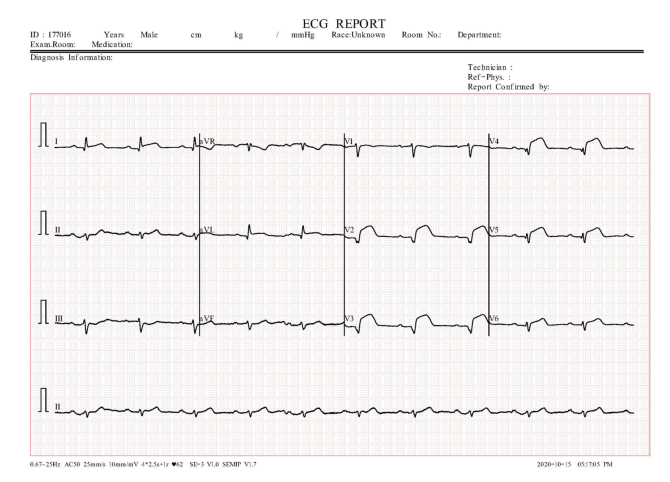

In [30]:
plt.figure(figsize=(12,6))
plt.imshow(imrgb)
plt.axis('off')
plt.show()